# Atividade Aplicação de Filtros em Imagens

## Alunos:
* Orlando Virginio Penha Junior - 122210927
* Everton Kauan Silva Oliveira - 122210386
* Vinícius Ian Alves Lopes - 122210392

This notebook demonstrates traditional image blurring (uniform and Gaussian), custom 2D convolution for sharpening, and exploration of adaptive blurring and sharpening techniques.

In [89]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import io

Loading an image and displaying its attributes

In [90]:
#img = io.imread('https://img.freepik.com/free-photo/girl-plays-with-sand-sahara-desert-erg-chebbi-merzouga-morocco_129479-355.jpg')
#img = io.imread('https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg')
!wget https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg
img = io.imread('000_8UA32F-1024x683.jpg')
print(img.shape)
print(img.dtype)

--2025-11-23 22:22:18--  https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg
Resolving www.cartacapital.com.br (www.cartacapital.com.br)... 172.67.72.223, 104.26.8.183, 104.26.9.183, ...
Connecting to www.cartacapital.com.br (www.cartacapital.com.br)|172.67.72.223|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105881 (103K) [image/jpeg]
Saving to: ‘000_8UA32F-1024x683.jpg.4’

000_8UA32F-1024x683 100%[===================>] 103.40K  --.-KB/s    in 0.002s  

2025-11-23 22:22:18 (44.9 MB/s) - ‘000_8UA32F-1024x683.jpg.4’ saved [105881/105881]

(683, 1024, 3)
uint8


Visualizing the image

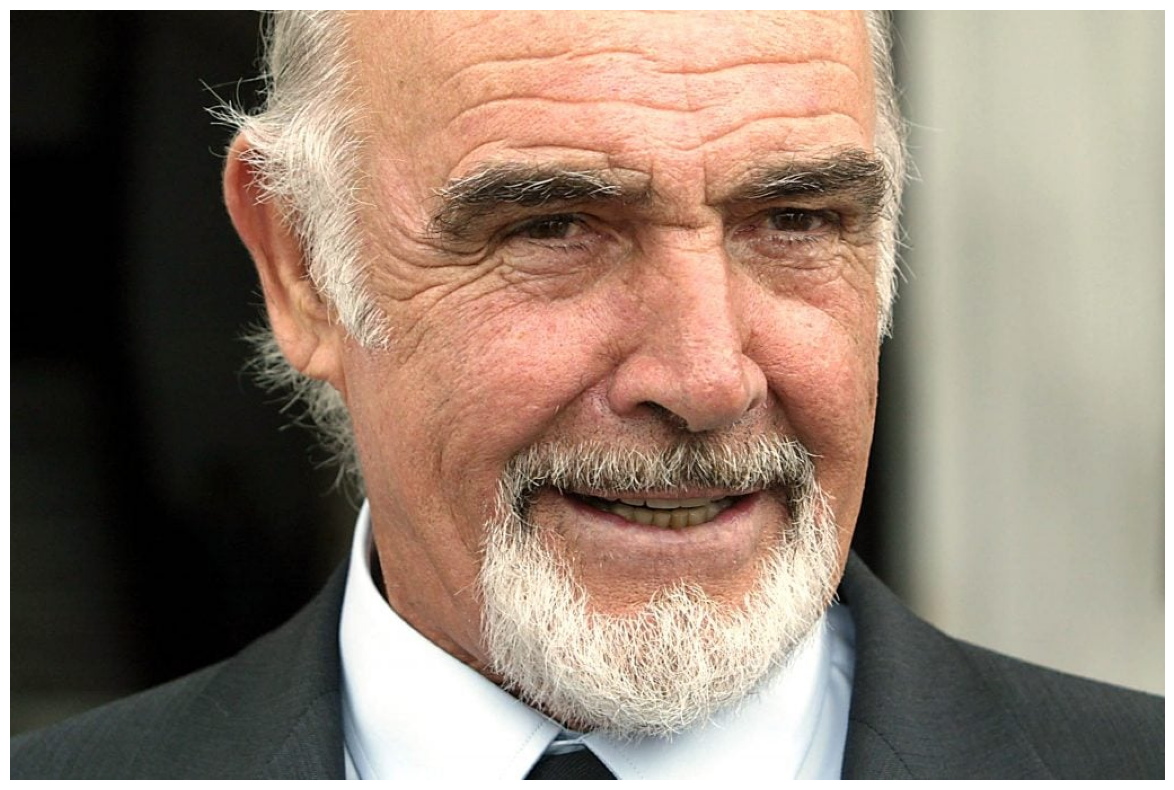

In [91]:
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

Comparing traditional blur (uniform weight mask) with gaussian blur (weights from Gaussian function)

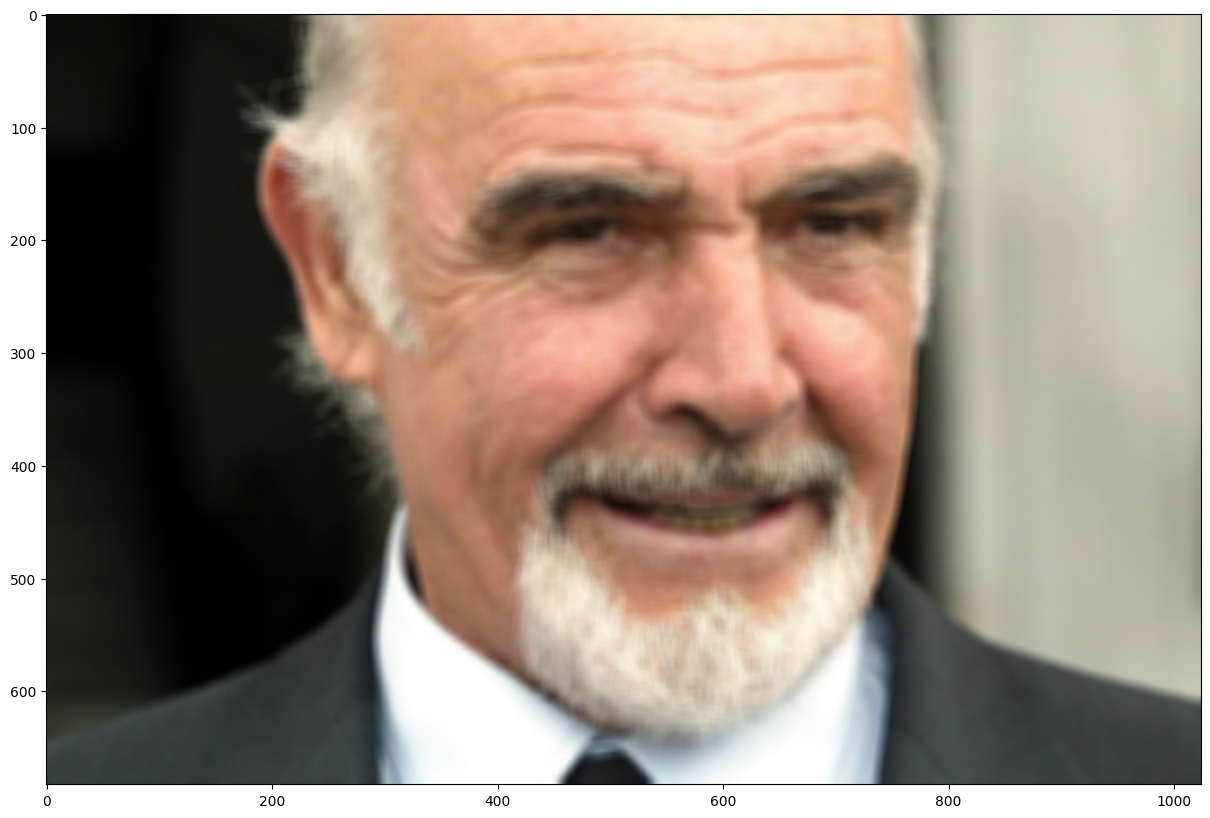

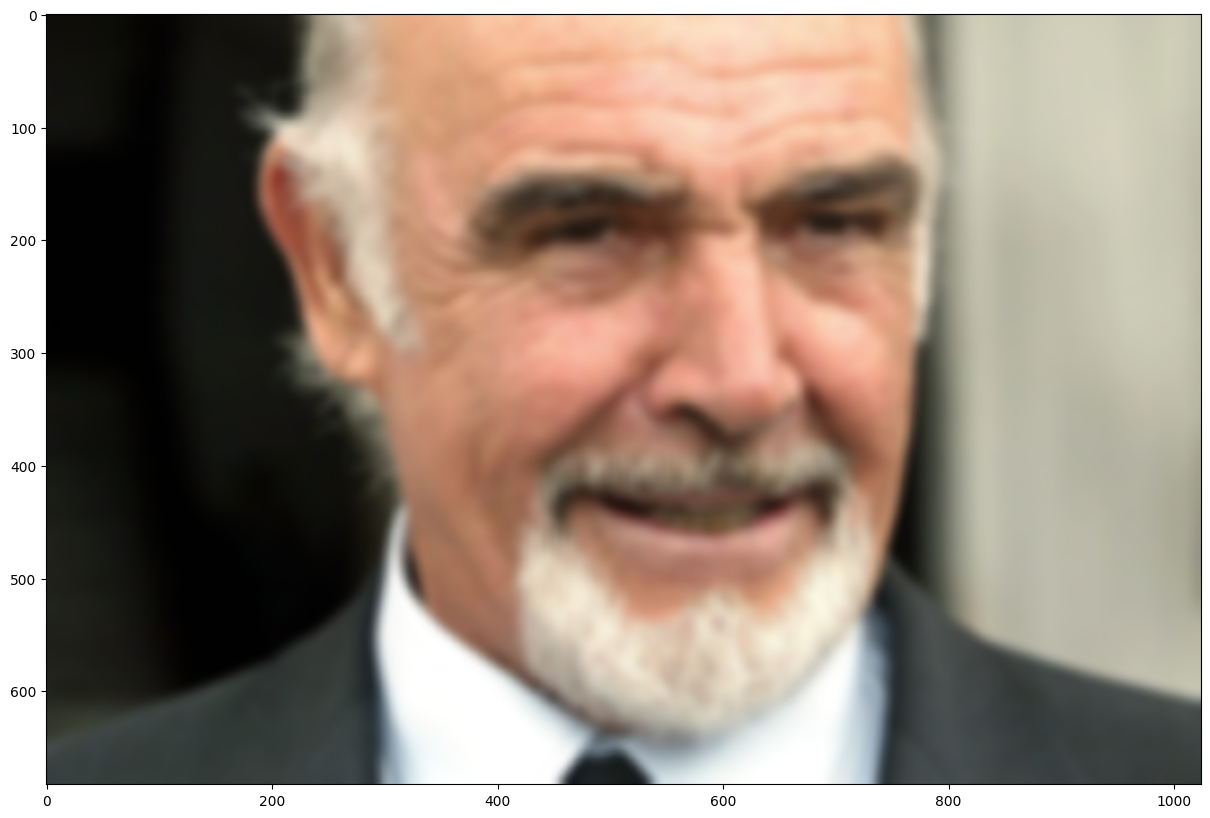

(683, 1024, 3)


In [92]:
plt.figure(figsize=(15, 10))
blur1 = cv.blur(img,(11,11))
plt.imshow(blur1)
plt.show()

plt.figure(figsize=(15, 10))
blur2 = cv.blur(blur1,(11,11))
plt.imshow(blur2)
plt.show()

print(blur2.shape)


Performing a 2D convolution using a custom mask (sharpening) and showing original and resulting images

In [93]:
plt.figure(figsize=(15, 10))

mask = np.array([[0, -2, 0],
                 [-2, 9, -2],
                 [0, -2, 0]])

result = cv.filter2D(img,-1,mask)
plt.imshow(img)
plt.show()

plt.figure(figsize=(15, 10))

plt.imshow(result)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Inspecting type of resulting image:

In [94]:
result.dtype

dtype('uint8')

Let's try different convolution masks.

How about designing convolution masks for detecting:
* vertical lines
* horizontal lines



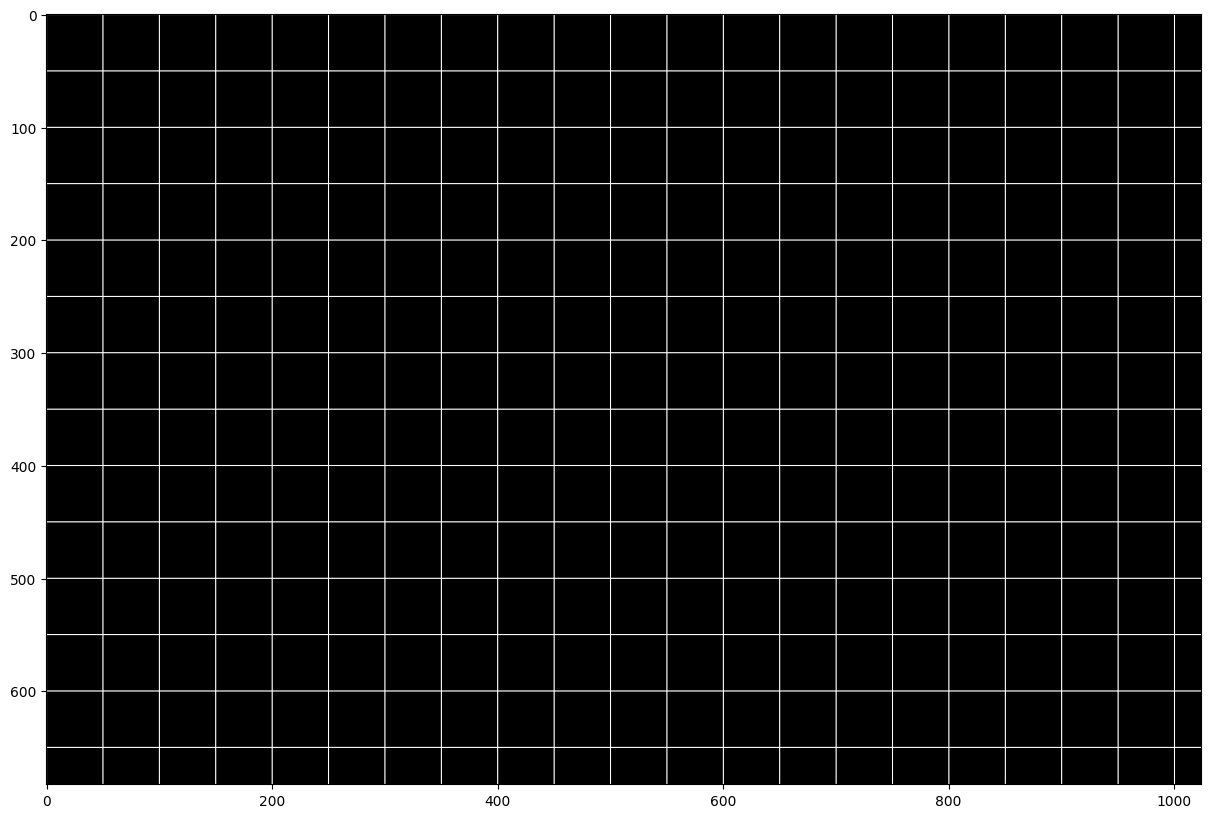

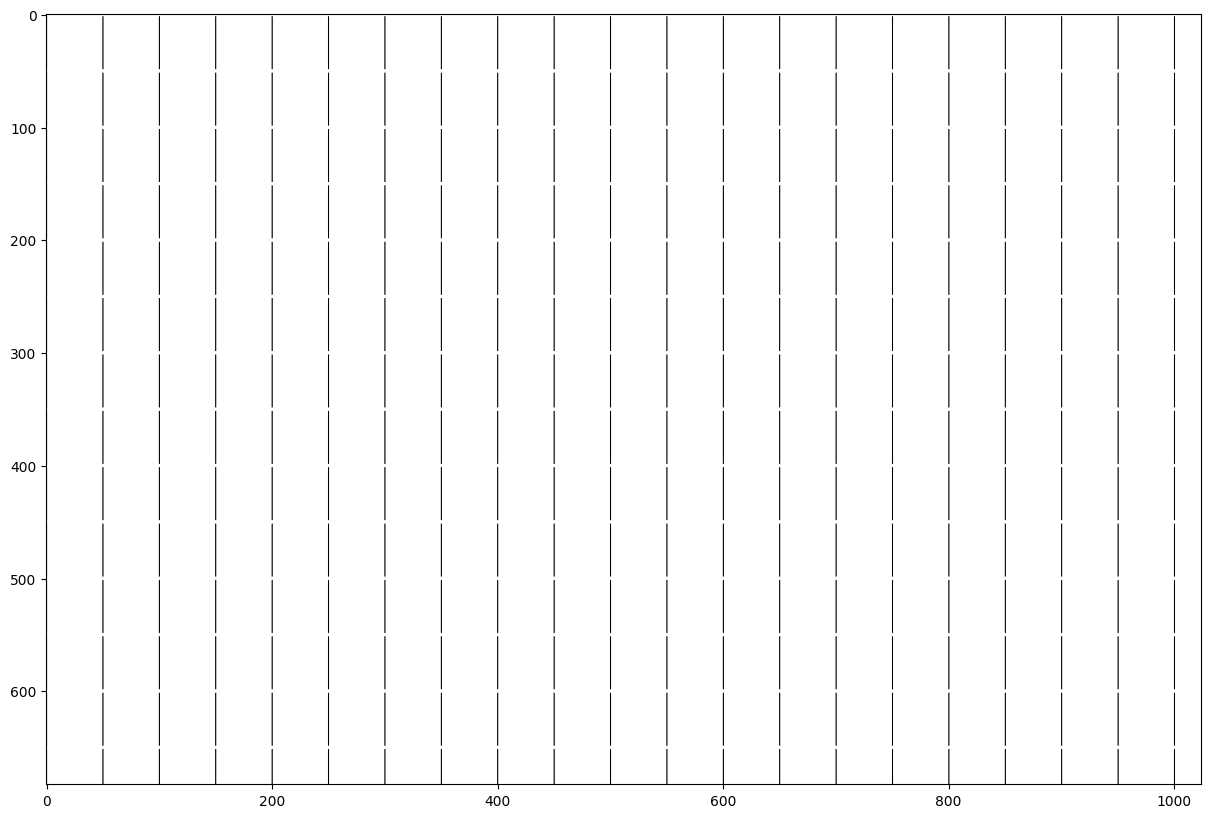

765.0 -765.0


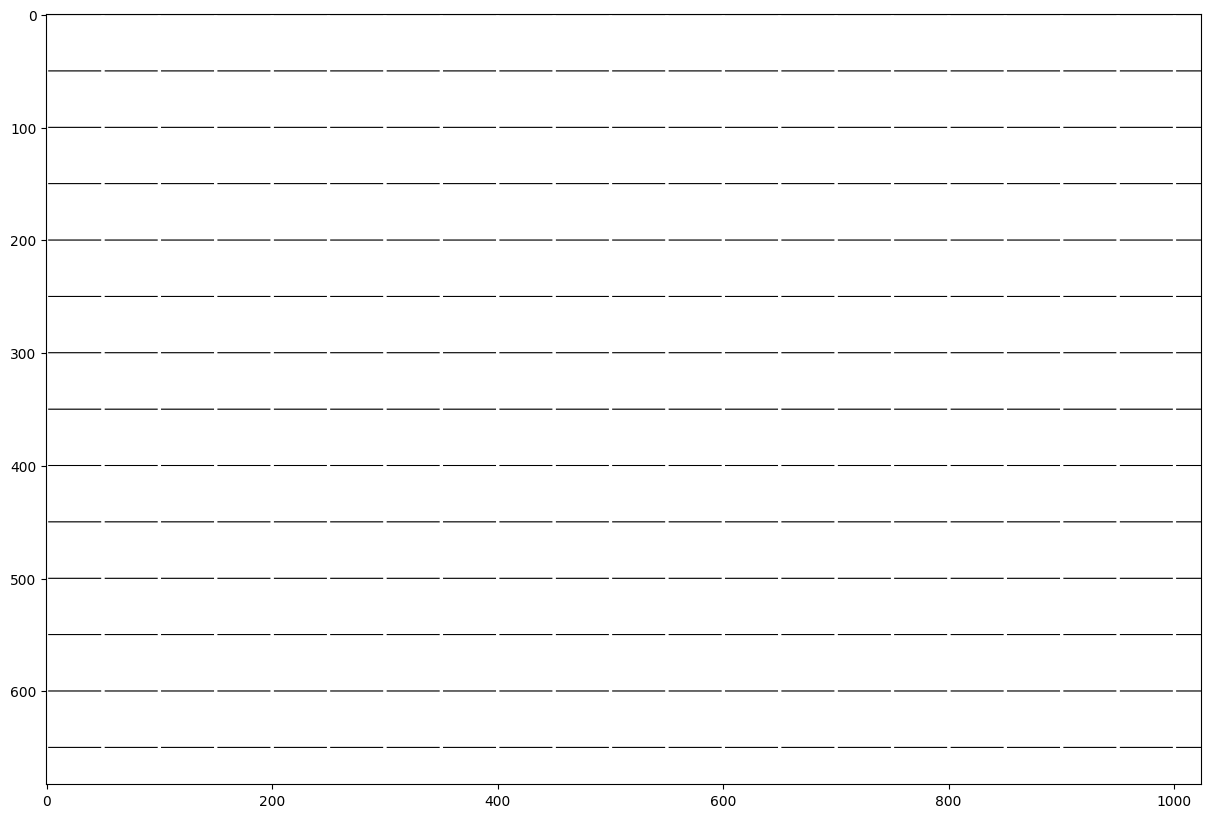

765.0 -765.0


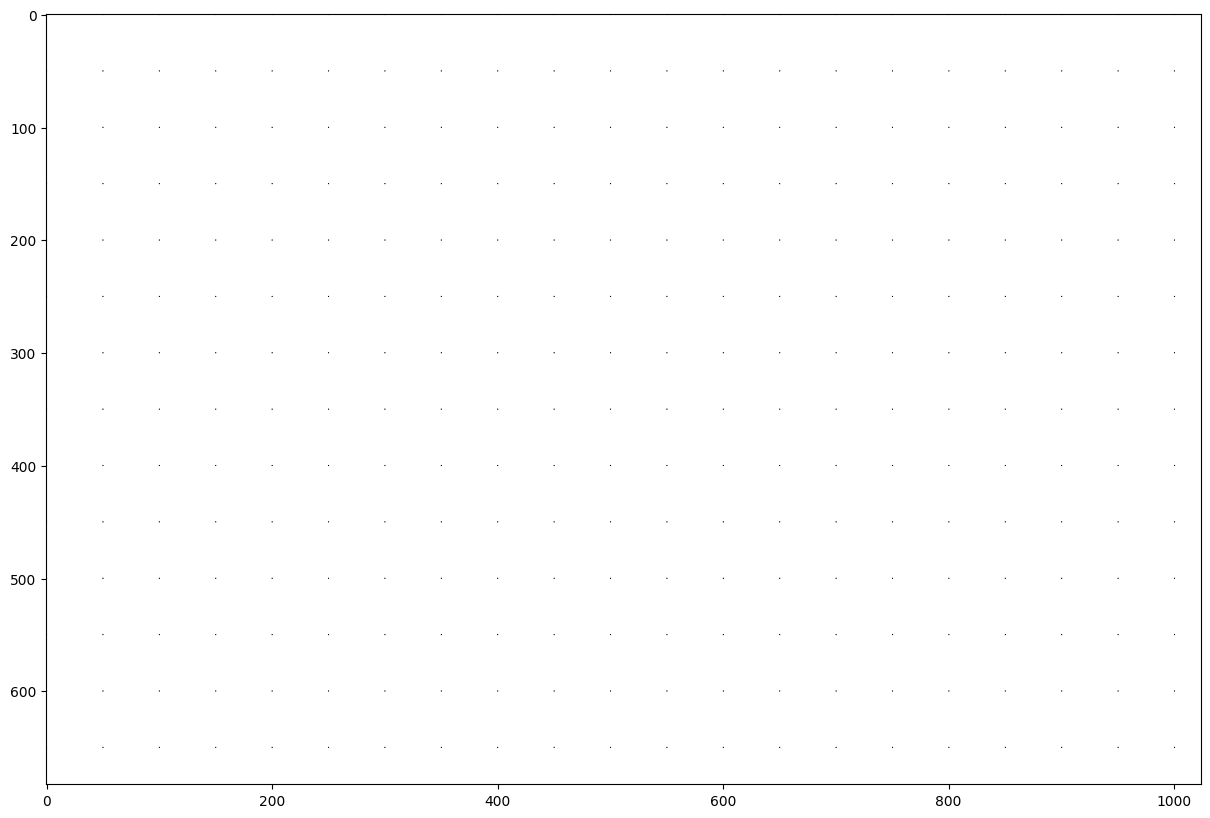

1275.0 -255.0


In [95]:
mask_vert = np.array([ [-1,   1,  -1],
                       [ -1,  1,  -1],
                       [-1,   1, -1]])

mask_horz = np.array([ [-1,  -1,  -1],
                       [ 1,  1,  1],
                       [-1,  -1, -1]])

mask_cross = np.array([ [-1,  1,  -1],
                       [  1,  1,   1],
                       [ -1,  1,  -1]])

new_img = np.zeros(img.shape)
y_size=new_img.shape[0]
x_size=new_img.shape[1]
new_img[0:y_size:50, 0:x_size]=255
new_img[0:y_size, 0:x_size:50]=255

plt.figure(figsize=(15, 10))
plt.imshow(new_img)
plt.show()

filters=[(mask_vert,600),(mask_horz,600), (mask_cross,800)]

for f,th in filters:
  result = cv.filter2D(new_img,-1,f)
  plt.figure(figsize=(15, 10))
  plt.imshow(result[:,:,0]<th,cmap='gray' )
  plt.show()
  print(np.max(result), np.min(result))

# Now is your turn.
Based on the following code:

1. Create your improved 2D convolution that performs an adaptive blur (blur
occurs only on local areas with low standard deviation). Choose an approriate mask size to create a visible smoothing effect on the skin.  Run your code on the same input color image shown at the begining of this notebook.

2. Create your improved 2D convolution that performs an adaptive sharpening (sharpening occurs only on local areas with high standard variation). Choose an approriate mask size to create a visible sharpening effect on the face area. Run your code on the same input color image shown at the begining of this notebook.

3. Use the original image to perform adaptive blur followed by adaptive shapening and vice-versa. Any differences in the results? Please comment on that.

Start with implementing the 2D convolution operation from scratch for a NxN blur operation.
Then include the needed tests and auxiliary functions to perform the adaptive blur and sharpening. Finally, include code to perform the required tests and add some comments about the obtained results.


## Questão 1:

(341, 512, 3)


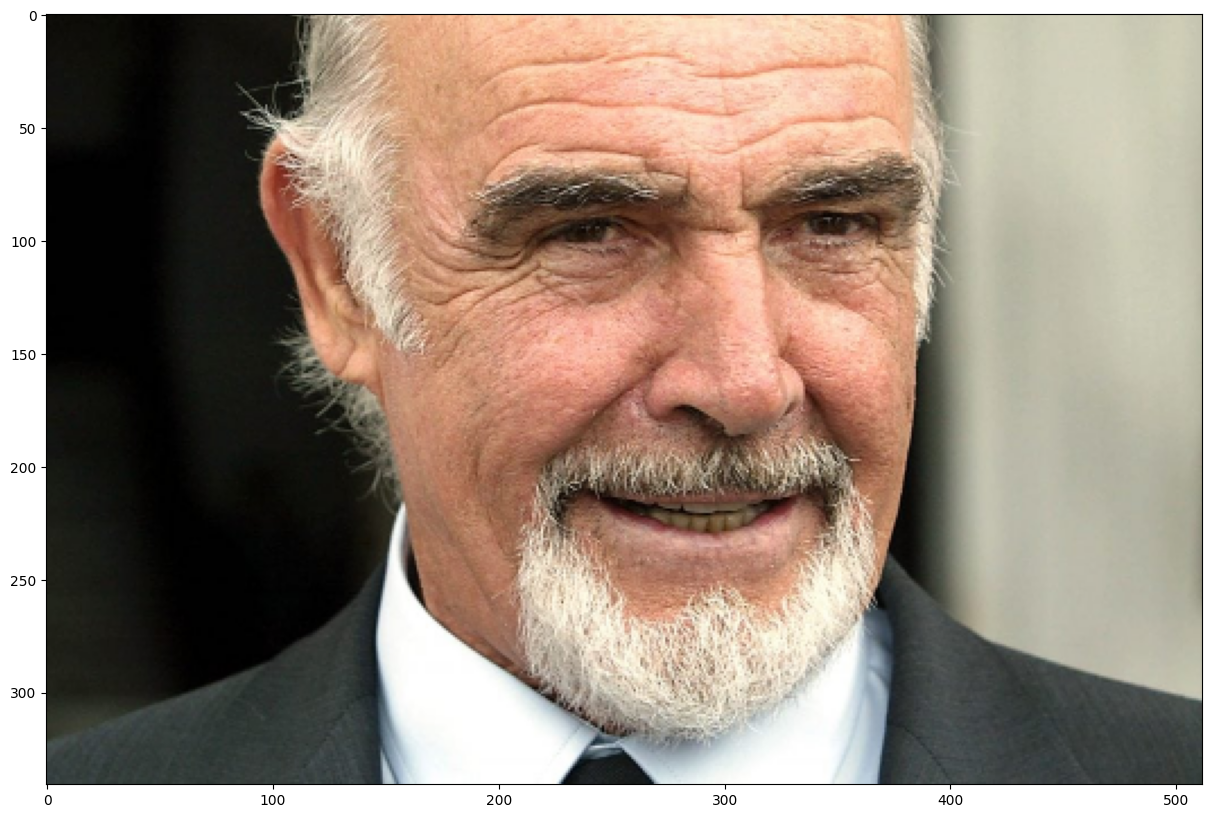

In [96]:
#resize the image to reduce computation costs
img = cv.resize(img,(int(img.shape[1]/2),int(img.shape[0]/2)))
print(img.shape)
#display the resulting image
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.show()

In [97]:
mask_size = 5
mask = np.ones((mask_size,mask_size))
mask = mask/(sum(mask)*sum(mask))
print(mask)


[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


In [98]:
# Calcula o desvio padrão do segmento local da imagem
# para determinar o se o filtro deve ou não ser aplicado.
def calc_std(img_crop):
  std = np.std(img_crop)
  return std

In [99]:
def adaptive_blur(mask_size, img, mask, threshold):

  img_blurred_cv = cv.filter2D(img, -1, mask)
  result = np.zeros(img.shape)
  tot_lin = img.shape[0]
  tot_col = img.shape[1]
  for color in range(0,3):
    for lin in range(mask_size-1,tot_lin):
      for col in range(mask_size-1,tot_col):
        img_crop = img[lin-mask_size:lin, col-mask_size:col, color]
        if calc_std(img_crop) > threshold: # Caso o desvio seja maior que o threshold, a máscara não é aplicada.
           result[lin,col,color]  = img[lin,col,color]
        else: # Aplicação da máscara de blur na região para suavizar as feições da face.
          result[lin,col,color] = img_blurred_cv[lin,col,color]
  result = result.astype(np.uint8)
  return result

Comentário: Criamos uma função para o blur adaptativo com filtro 2D de convolução. Estamos preservando as bordas (onde o desvio padrão é alto, como na barba e cabelos) e suavizando áreas lisas (como a pele da testa)

In [100]:
# Faz o teste com blur adapatativo
img_blurred = adaptive_blur(mask_size, img, mask, 10)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


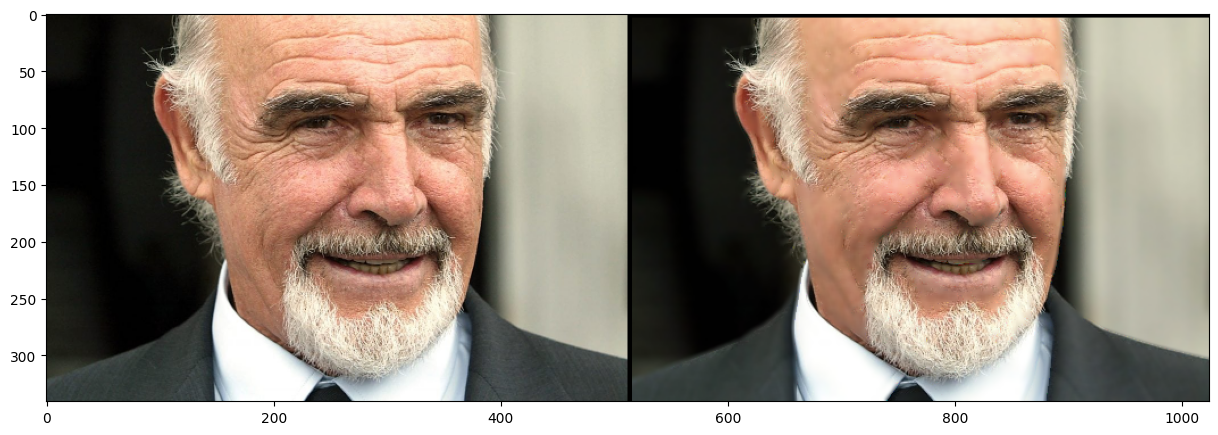

In [101]:
#display the result as an image
plt.figure(figsize=(15, 10))
result = cv.hconcat((img,img_blurred))
plt.imshow(result)

## Questão 2

In [102]:
def adapatative_sharpening(img, mask, mask_size, threshold):
    img_sharpened = cv.filter2D(img, -1, mask)
    result = np.zeros(img.shape)
    t_lin = img.shape[0]
    t_col = img.shape[1]

    for cor in range(0, 3):
        for lin in range(mask_size-1, t_lin):
            for col in range(mask_size-1, t_col):
                img_crop = img[lin - mask_size:lin, col-mask_size:col, cor]
                if calc_std(img_crop) > threshold:
                    result[lin, col, cor] = img_sharpened[lin, col, cor]
                else:
                    result[lin, col, cor] = img[lin, col, cor]
    result = result.astype(np.uint8)
    return result

Comentário: Criamos uma função para o sharpening com filtro 2D de convolução. Estamos realçando as bordas aumentando o pixel central e diminuindo seus vizinhos, se o desvio padrão entre essas regiões for muito alto, a borda é realçada

In [103]:
# Faz o teste com a máscara de sharpening
mask = np.array([[0, -2, 0],
                 [-2, 9, -2],
                 [0, -2, 0]])

new_image = adapatative_sharpening(img, mask, 3, 10)

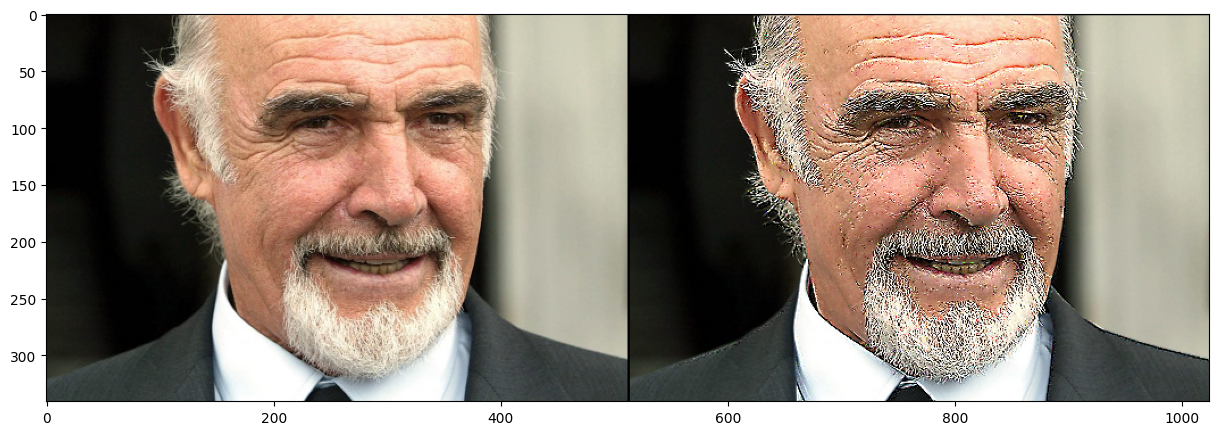

In [104]:
plt.figure(figsize=(15, 10))
result = cv.hconcat((img,new_image))
plt.imshow(result)
plt.show()



## Questão 3

In [105]:
# Máscara de sharpening
sharp_mask = np.array([[0, -2, 0],
                       [-2, 9, -2],
                       [0, -2, 0]])

# Máscara de blur
mask_size = 5
mask = np.ones((mask_size,mask_size))
blur_mask = mask/(sum(mask)*sum(mask))

# Imagem com blur aplicado
img_blur = adaptive_blur(mask_size, img, blur_mask, 10)

# Imagem com sharpening aplicado
img_sharp = adapatative_sharpening(img, sharp_mask, 3, 10)

# Sharpening aplicado sobre o blur
img_blur_then_sharp = adapatative_sharpening(img_blur, sharp_mask, 3, 10)

# Blur aplicado sobre o sharpening
img_sharp_then_blur = adaptive_blur(mask_size, img_sharp, blur_mask, 10)


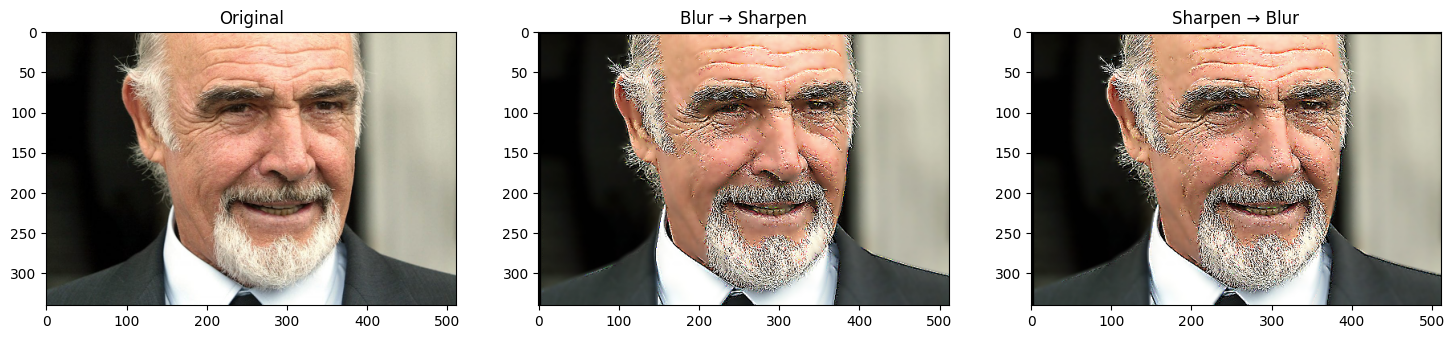

In [106]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original')

plt.subplot(1,3,2)
plt.imshow(img_blur_then_sharp)
plt.title('Blur → Sharpen')

plt.subplot(1,3,3)
plt.imshow(img_sharp_then_blur)
plt.title('Sharpen → Blur')
plt.show()


## Questão 3 - Conclusão

A diferença é sutil, mas na imagem central (Blur → Sharpen) como o blur foi aplicado primeiro, regiões que seriam tratadas como borda, foram levemente suavizadas, fazendo com que após a aplicação do sharpening, a presença de regiões de borda fosse reduzida, já na imagem da direita (Sharpen → Blur), tivemos uma atenuação das bordas, aumentando o desvio padrão entre alguns pixels de regiões mais suaves, fazendo com que mesmo após o blur, algumas regiões ainda apresentem um sharpening mais evidente que na imagem anterior.